In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for our plots
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

In [10]:
# Load the data
df = pd.read_csv("C:\\Users\\Scaipl\\Downloads\\Fifa_world_cup_matches.csv")

# Fix column names by stripping whitespace
df.columns = [col.strip() for col in df.columns]

# Convert possession percentages to numeric values
df['possession team1'] = df['possession team1'].str.rstrip('%').astype(float)
df['possession team2'] = df['possession team2'].str.rstrip('%').astype(float)

# Display first few rows to verify data loading correctly
df.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42.0,50.0,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72.0,19.0,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44.0,45.0,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51.0,39.0,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64.0,24.0,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


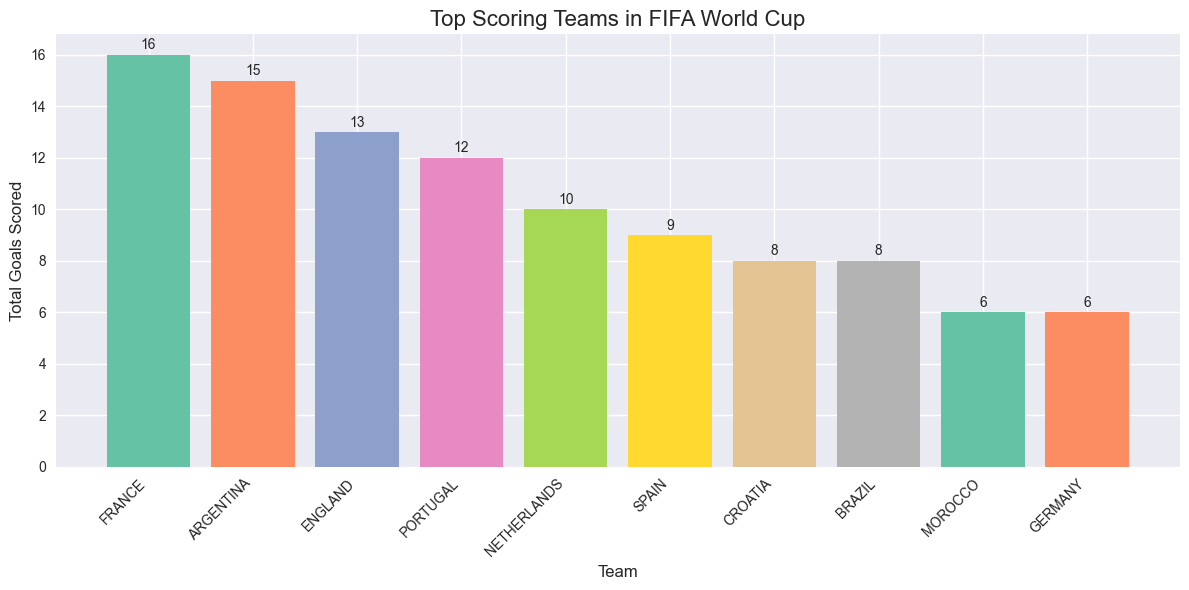

           Team  Goals
7        FRANCE     16
4     ARGENTINA     15
1       ENGLAND     13
14     PORTUGAL     12
17  NETHERLANDS     10
10        SPAIN      9
21      CROATIA      8
15       BRAZIL      8
8       MOROCCO      6
9       GERMANY      6


In [11]:
def plot_top_scoring_teams(df, n=10):
    """Plot the top n scoring teams in the tournament."""
    # Create a dictionary to count goals by team
    team_goals = {}
    
    # Aggregate goals for team1
    for team, goals in zip(df['team1'], df['number of goals team1']):
        if team in team_goals:
            team_goals[team] += goals
        else:
            team_goals[team] = goals
    
    # Aggregate goals for team2
    for team, goals in zip(df['team2'], df['number of goals team2']):
        if team in team_goals:
            team_goals[team] += goals
        else:
            team_goals[team] = goals
    
    # Convert to DataFrame and sort
    team_goals_df = pd.DataFrame(list(team_goals.items()), columns=['Team', 'Goals'])
    team_goals_df = team_goals_df.sort_values('Goals', ascending=False).head(n)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(team_goals_df['Team'], team_goals_df['Goals'], color=sns.color_palette("Set2", n))
    
    # Add data labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.0f}', ha='center', va='bottom')
    
    plt.title('Top Scoring Teams in FIFA World Cup', fontsize=16)
    plt.xlabel('Team', fontsize=12)
    plt.ylabel('Total Goals Scored', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return team_goals_df

# Execute the function
top_teams = plot_top_scoring_teams(df)
print(top_teams)

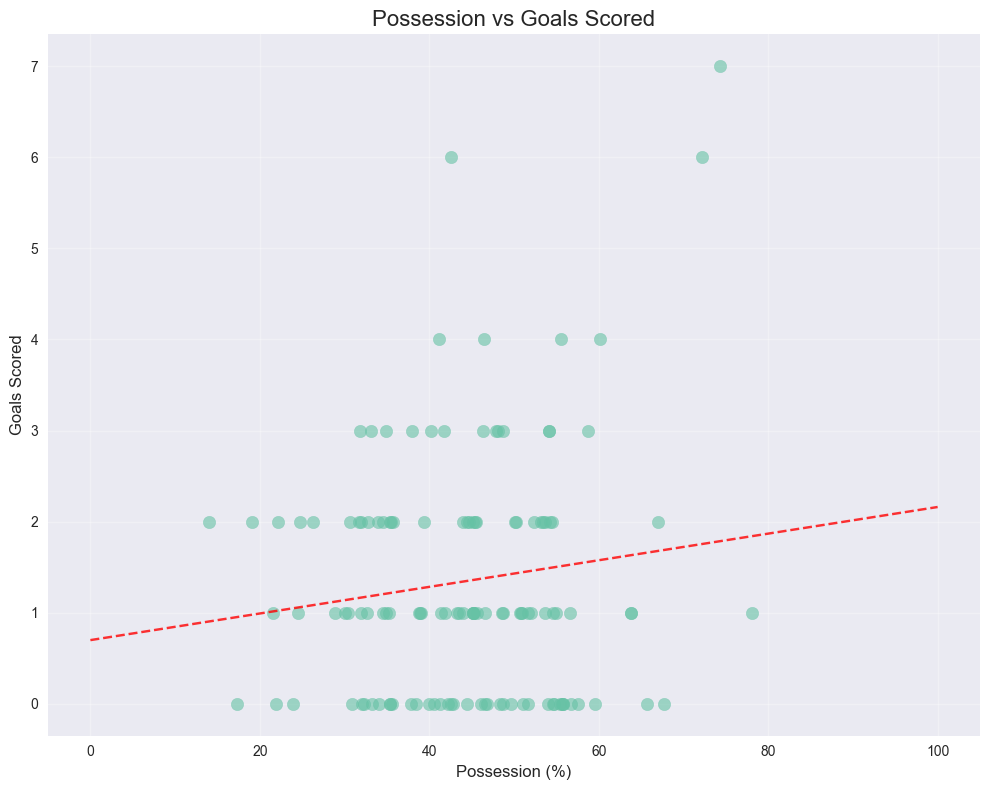

In [13]:
def plot_possession_vs_goals(df):
    """Create a scatter plot showing the relationship between possession and goals."""
    # Prepare data
    team1_data = pd.DataFrame({
        'Team': df['team1'],
        'Possession': df['possession team1'],
        'Goals': df['number of goals team1']
    })
    
    team2_data = pd.DataFrame({
        'Team': df['team2'],
        'Possession': df['possession team2'],
        'Goals': df['number of goals team2']
    })
    
    # Combine data
    possession_goals = pd.concat([team1_data, team2_data])
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Plot points with jitter to avoid overlap
    x = possession_goals['Possession']
    y = possession_goals['Goals']
    x_jitter = x + np.random.normal(0, 0.5, len(x))
    
    plt.scatter(x_jitter, y, alpha=0.6, s=80)
    
    # Add trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(range(0, 101, 5), p(range(0, 101, 5)), "r--", alpha=0.8)
    
    plt.title('Possession vs Goals Scored', fontsize=16)
    plt.xlabel('Possession (%)', fontsize=12)
    plt.ylabel('Goals Scored', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execute the function
plot_possession_vs_goals(df)

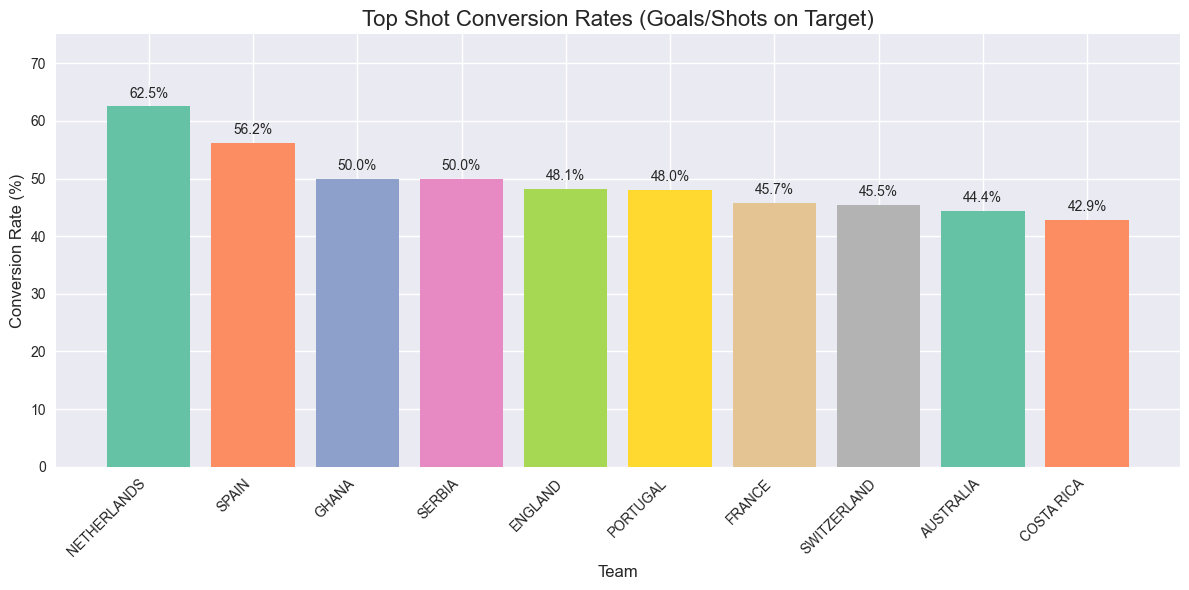

           Team  Goals  Shots_On_Target  Conversion_Rate
19  NETHERLANDS     10               16        62.500000
26        SPAIN      9               16        56.250000
13        GHANA      5               10        50.000000
25       SERBIA      5               10        50.000000
10      ENGLAND     13               27        48.148148
21     PORTUGAL     12               25        48.000000
11       FRANCE     16               35        45.714286
27  SWITZERLAND      5               11        45.454545
1     AUSTRALIA      4                9        44.444444
6    COSTA RICA      3                7        42.857143


In [14]:
def plot_shot_conversion(df):
    """Plot shot conversion rate (goals/shots on target) for teams with highest rates."""
    # Prepare data
    team1_data = pd.DataFrame({
        'Team': df['team1'],
        'Goals': df['number of goals team1'],
        'Shots_On_Target': df['on target attempts team1']
    })
    
    team2_data = pd.DataFrame({
        'Team': df['team2'],
        'Goals': df['number of goals team2'],
        'Shots_On_Target': df['on target attempts team2']
    })
    
    # Combine data
    shots_data = pd.concat([team1_data, team2_data])
    
    # Group by team and calculate conversion rate
    team_shots = shots_data.groupby('Team').sum().reset_index()
    team_shots['Conversion_Rate'] = team_shots['Goals'] / team_shots['Shots_On_Target'] * 100
    team_shots = team_shots.replace([np.inf, -np.inf], np.nan).dropna()  # Handle division by zero
    
    # Select teams with at least 5 shots on target
    team_shots = team_shots[team_shots['Shots_On_Target'] >= 5]
    
    # Sort and take top 10
    team_shots = team_shots.sort_values('Conversion_Rate', ascending=False).head(10)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(team_shots['Team'], team_shots['Conversion_Rate'], color=sns.color_palette("Set2", 10))
    
    # Add data labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    plt.title('Top Shot Conversion Rates (Goals/Shots on Target)', fontsize=16)
    plt.xlabel('Team', fontsize=12)
    plt.ylabel('Conversion Rate (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(team_shots['Conversion_Rate']) * 1.2)
    plt.tight_layout()
    plt.show()
    
    return team_shots

# Execute the function
shot_conversion = plot_shot_conversion(df)
print(shot_conversion)

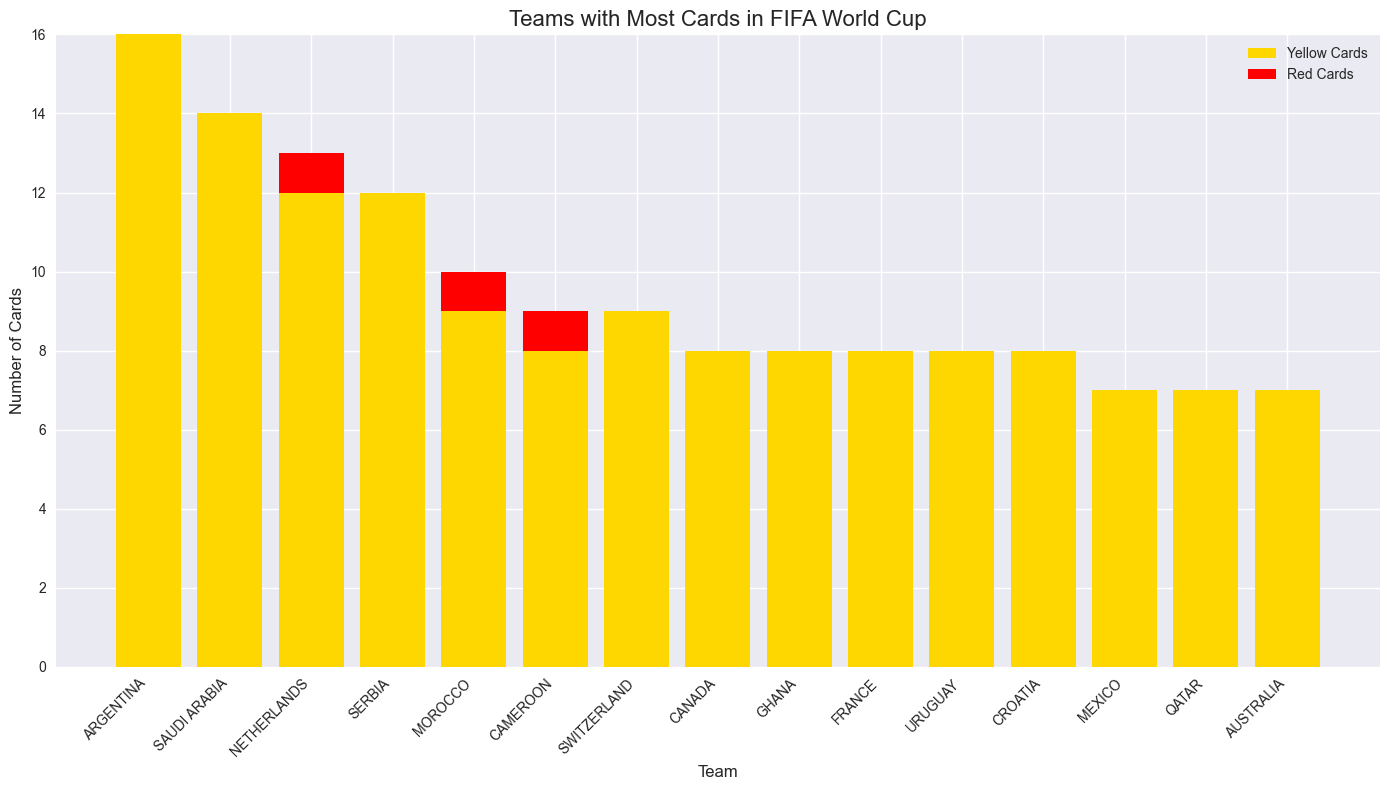

            Team  Yellow_Cards  Red_Cards  Total
0      ARGENTINA            16          0     16
23  SAUDI ARABIA            14          0     14
19   NETHERLANDS            12          1     13
25        SERBIA            12          0     12
18       MOROCCO             9          1     10
4       CAMEROON             8          1      9
27   SWITZERLAND             9          0      9
5         CANADA             8          0      8
13         GHANA             8          0      8
11        FRANCE             8          0      8
30       URUGUAY             8          0      8
7        CROATIA             8          0      8
17        MEXICO             7          0      7
22         QATAR             7          0      7
1      AUSTRALIA             7          0      7


In [15]:
def plot_cards_by_team(df):
    """Plot yellow and red cards by team."""
    # Prepare data
    team1_data = pd.DataFrame({
        'Team': df['team1'],
        'Yellow_Cards': df['yellow cards team1'],
        'Red_Cards': df['red cards team1']
    })
    
    team2_data = pd.DataFrame({
        'Team': df['team2'],
        'Yellow_Cards': df['yellow cards team2'],
        'Red_Cards': df['red cards team2']
    })
    
    # Combine data
    cards_data = pd.concat([team1_data, team2_data])
    
    # Group by team
    team_cards = cards_data.groupby('Team').sum().reset_index()
    team_cards['Total'] = team_cards['Yellow_Cards'] + team_cards['Red_Cards']
    
    # Sort and take top 15
    team_cards = team_cards.sort_values('Total', ascending=False).head(15)
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    
    # Create stacked bar chart
    bars1 = plt.bar(team_cards['Team'], team_cards['Yellow_Cards'], color='#FFD700', label='Yellow Cards')
    bars2 = plt.bar(team_cards['Team'], team_cards['Red_Cards'], color='#FF0000', 
                   bottom=team_cards['Yellow_Cards'], label='Red Cards')
    
    plt.title('Teams with Most Cards in FIFA World Cup', fontsize=16)
    plt.xlabel('Team', fontsize=12)
    plt.ylabel('Number of Cards', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return team_cards

# Execute the function
cards = plot_cards_by_team(df)
print(cards)

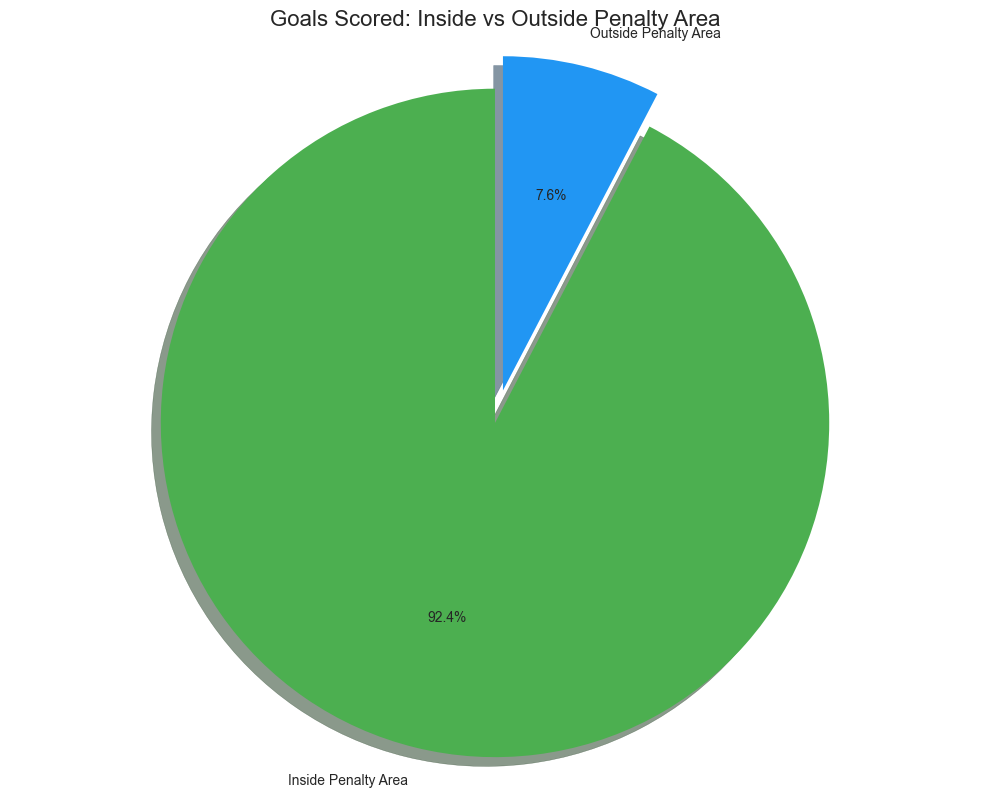

               Location  Goals  Percentage
0   Inside Penalty Area    157   92.352941
1  Outside Penalty Area     13    7.647059


In [16]:
def plot_goals_by_area(df):
    """Plot comparison of goals scored inside vs outside penalty area."""
    # Prepare data
    total_inside = df['goal inside the penalty area team1'].sum() + df['goal inside the penalty area team2'].sum()
    total_outside = df['goal outside the penalty area team1'].sum() + df['goal outside the penalty area team2'].sum()
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Create pie chart
    labels = ['Inside Penalty Area', 'Outside Penalty Area']
    sizes = [total_inside, total_outside]
    explode = (0.1, 0)  # explode the 1st slice for emphasis
    
    plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
            shadow=True, startangle=90, colors=['#4CAF50', '#2196F3'])
    
    # Equal aspect ratio ensures that pie is drawn as a circle
    plt.axis('equal')
    plt.title('Goals Scored: Inside vs Outside Penalty Area', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame({
        'Location': labels,
        'Goals': sizes,
        'Percentage': [s/sum(sizes)*100 for s in sizes]
    })

# Execute the function
goals_area = plot_goals_by_area(df)
print(goals_area)


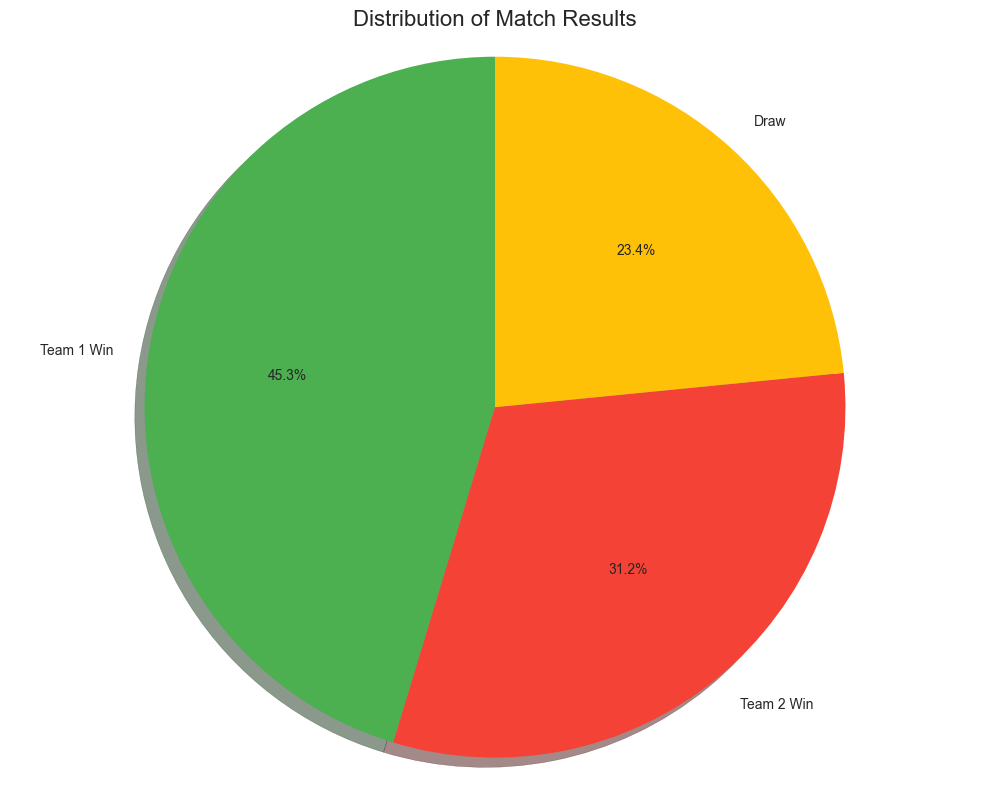

       Result  Count  Percentage
0  Team 1 Win     29     45.3125
1  Team 2 Win     20     31.2500
2        Draw     15     23.4375


In [17]:
def plot_match_results(df):
    """Plot distribution of match results (win/loss/draw)."""
    results = []
    
    for _, match in df.iterrows():
        goals1 = match['number of goals team1']
        goals2 = match['number of goals team2']
        
        if goals1 > goals2:
            results.append('Team 1 Win')
        elif goals2 > goals1:
            results.append('Team 2 Win')
        else:
            results.append('Draw')
    
    # Count occurrences
    result_counts = pd.Series(results).value_counts()
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Create pie chart
    labels = result_counts.index
    sizes = result_counts.values
    colors = ['#4CAF50', '#F44336', '#FFC107']
    
    plt.pie(sizes, labels=labels, autopct='%1.1f%%',
            shadow=True, startangle=90, colors=colors)
    
    # Equal aspect ratio ensures that pie is drawn as a circle
    plt.axis('equal')
    plt.title('Distribution of Match Results', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame({
        'Result': labels,
        'Count': sizes,
        'Percentage': [s/sum(sizes)*100 for s in sizes]
    })

# Execute the function
match_results = plot_match_results(df)
print(match_results)

In [18]:
# Print some summary info
print("Summary Statistics:")
print(f"Total matches analyzed: {len(df)}")
print(f"Total goals scored: {df['number of goals team1'].sum() + df['number of goals team2'].sum()}")
print(f"Average goals per match: {(df['number of goals team1'].sum() + df['number of goals team2'].sum()) / len(df):.2f}")

# Find highest scoring match
highest_scoring_idx = (df['number of goals team1'] + df['number of goals team2']).idxmax()
highest_match = df.iloc[highest_scoring_idx]
print(f"Highest scoring match: {highest_match['team1']} vs {highest_match['team2']} "
      f"({highest_match['number of goals team1']}-{highest_match['number of goals team2']})")

# Get some stats from our previous analyses
print("\nTop scoring team:", top_teams.iloc[0]['Team'], f"with {top_teams.iloc[0]['Goals']} goals")
print("Team with best shot conversion rate:", shot_conversion.iloc[0]['Team'], 
      f"with {shot_conversion.iloc[0]['Conversion_Rate']:.1f}% conversion")
print("Team with most cards:", cards.iloc[0]['Team'], 
      f"with {cards.iloc[0]['Total']} cards ({cards.iloc[0]['Yellow_Cards']} yellow, {cards.iloc[0]['Red_Cards']} red)")

Summary Statistics:
Total matches analyzed: 64
Total goals scored: 172
Average goals per match: 2.69
Highest scoring match: ENGLAND vs IRAN (6-2)

Top scoring team: FRANCE with 16 goals
Team with best shot conversion rate: NETHERLANDS with 62.5% conversion
Team with most cards: ARGENTINA with 16 cards (16 yellow, 0 red)


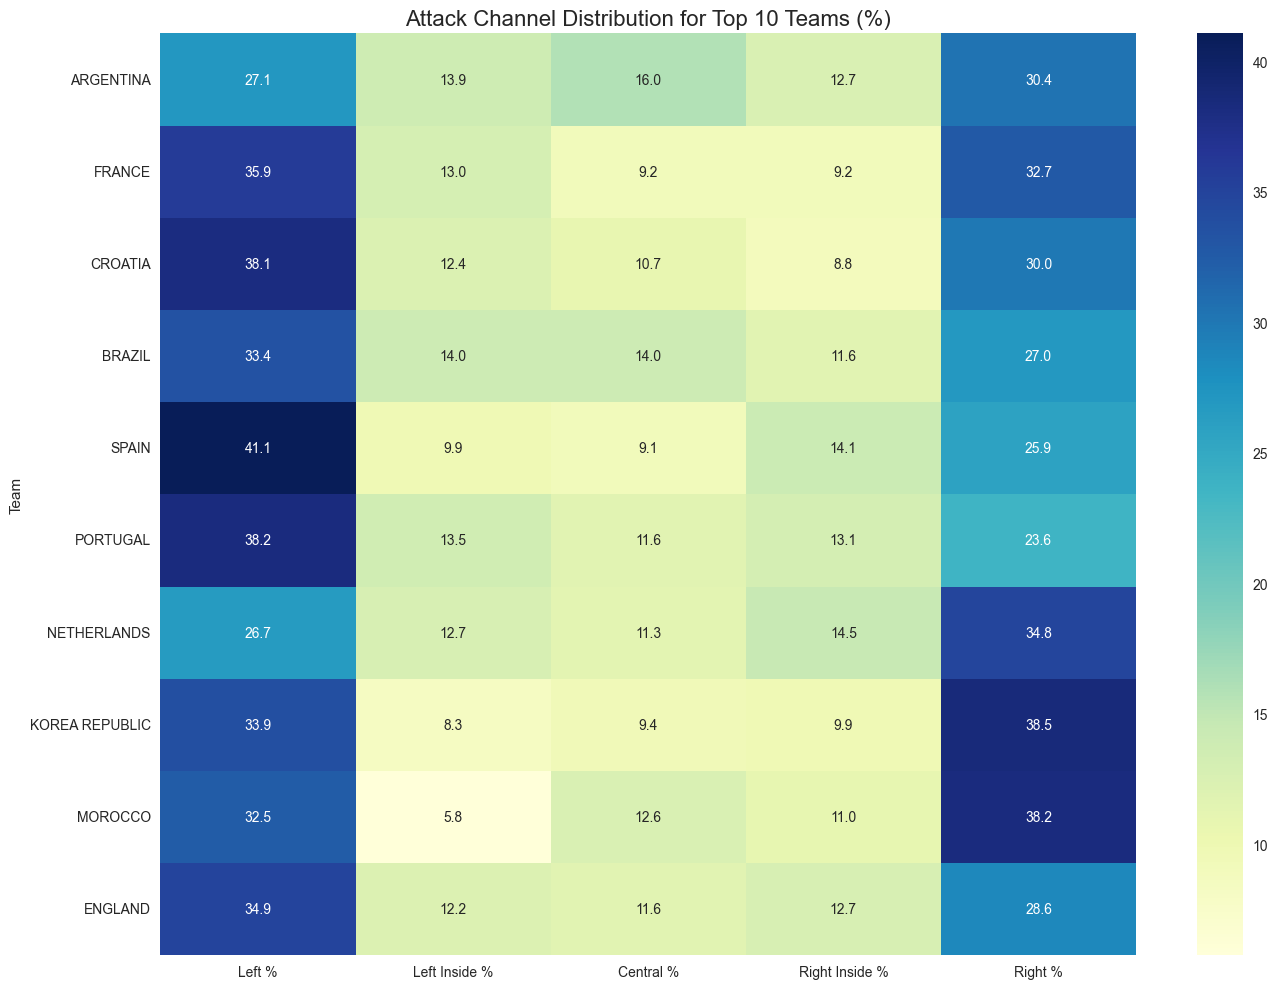

                Left  Left Inside  Central  Right Inside  Right  Total  \
Team                                                                     
ARGENTINA         90           46       53            42    101    332   
FRANCE           113           41       29            29    103    315   
CROATIA          117           38       33            27     92    307   
BRAZIL            98           41       41            34     79    293   
SPAIN            108           26       24            37     68    263   
PORTUGAL          99           35       30            34     61    259   
NETHERLANDS       59           28       25            32     77    221   
KOREA REPUBLIC    65           16       18            19     74    192   
MOROCCO           62           11       24            21     73    191   
ENGLAND           66           23       22            24     54    189   

                   Left %  Left Inside %  Central %  Right Inside %    Right %  
Team                          

In [19]:
# Create a heatmap showing which teams prefer which attack channels
def plot_attack_channels(df):
    # Select only the needed columns for team1
    channels_team1 = df[['team1', 'left channel team1', 'left inside channel team1', 
                        'central channel team1', 'right inside channel team1', 'right channel team1']]
    
    # Rename columns for clarity when we combine
    channels_team1.columns = ['Team', 'Left', 'Left Inside', 'Central', 'Right Inside', 'Right']
    
    # Select only the needed columns for team2
    channels_team2 = df[['team2', 'left channel team2', 'left inside channel team2', 
                        'central channel team2', 'right inside channel team2', 'right channel team2']]
    
    # Rename columns for clarity when we combine
    channels_team2.columns = ['Team', 'Left', 'Left Inside', 'Central', 'Right Inside', 'Right']
    
    # Combine data from both teams
    all_channels = pd.concat([channels_team1, channels_team2])
    
    # Group by team and sum the values
    team_channels = all_channels.groupby('Team').sum()
    
    # Get total attacks for each team to calculate percentages
    team_channels['Total'] = team_channels.sum(axis=1)
    
    # Calculate percentages
    for col in ['Left', 'Left Inside', 'Central', 'Right Inside', 'Right']:
        team_channels[f'{col} %'] = team_channels[col] / team_channels['Total'] * 100
    
    # Select top 10 teams based on total attacks
    top_teams_channels = team_channels.sort_values('Total', ascending=False).head(10)
    
    # Create a heatmap of the percentages
    plt.figure(figsize=(14, 10))
    percentage_cols = ['Left %', 'Left Inside %', 'Central %', 'Right Inside %', 'Right %']
    sns.heatmap(top_teams_channels[percentage_cols], annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title('Attack Channel Distribution for Top 10 Teams (%)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return top_teams_channels

# Execute the function
attack_channels = plot_attack_channels(df)
print(attack_channels)